# Sentiment Analysis of McDonald's Google-Maps Reviews
**Capstone Project II (DS3206) — Implementation Phase A12**

This notebook implements:
- **A12_ii** — Data Cleaning & Preprocessing
- **A12_iii** — Application of Analytical & Modelling Techniques (EDA, NLP, ML models, VADER lexicon baseline)
- **A12_iv** — Interpretation of Results & Insights (see accompanying report, `Sentiment_Analysis_Report.docx`, for the full write-up)

Data source: `DATASET.csv` — 33,396 Google Maps reviews of McDonald's outlets (A12_i, previously acquired).

## 1. Data Cleaning & Preprocessing (A12_ii)
Fixes encoding artifacts, parses ratings/time fields, removes duplicates and unusable rows, flags Google's auto-generated rating tags (no free text), and derives a sentiment label from the star rating.

In [2]:
"""
A12_ii - Data Cleaning and Preprocessing
Sentiment Analysis of McDonald's Store Reviews
"""
import re
import pandas as pd
import numpy as np

RAW_PATH = "DATASET.csv"
OUT_PATH = "cleaned_reviews.csv"

df = pd.read_csv(RAW_PATH, encoding="cp1252")
print("Raw shape:", df.shape)

# ---------------------------------------------------------------
# 1. Fix corrupted / mis-encoded store name (e.g. "ýýýMcDonald's")
# ---------------------------------------------------------------
df["store_name"] = df["store_name"].astype(str).str.replace(
    r"^[^A-Za-z0-9]+", "", regex=True
).str.strip()

# ---------------------------------------------------------------
# 2. Convert star-rating text ("1 star" / "5 stars") -> integer 1-5
# ---------------------------------------------------------------
df["rating_num"] = df["rating"].astype(str).str.extract(r"(\d)").astype(int)

# ---------------------------------------------------------------
# 3. Convert rating_count "1,240" -> integer
# ---------------------------------------------------------------
df["rating_count_num"] = (
    df["rating_count"].astype(str).str.replace(",", "", regex=False).astype(int)
)

# ---------------------------------------------------------------
# 4. Convert relative review_time ("3 months ago") -> approx days ago
# ---------------------------------------------------------------
def relative_to_days(text):
    text = str(text).lower().strip()
    m = re.match(r"(a|an|\d+)\s+(day|week|month|year|hour|minute)s?\s+ago", text)
    if not m:
        return np.nan
    qty, unit = m.groups()
    qty = 1 if qty in ("a", "an") else int(qty)
    mult = {"minute": 1/1440, "hour": 1/24, "day": 1, "week": 7,
             "month": 30, "year": 365}[unit]
    return qty * mult

df["days_ago"] = df["review_time"].apply(relative_to_days)

# ---------------------------------------------------------------
# 5. Clean review text
#    - fix mojibake artifacts (ï¿½ , ý  from bad cp1252/utf8 decode)
#    - strip control chars, normalise whitespace
# ---------------------------------------------------------------
def clean_text(t):
    t = str(t)
    t = t.replace("\\n", " ")
    # remove replacement-character mojibake sequences
    t = re.sub(r"[ï¿½ý]+", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df["review_clean"] = df["review"].apply(clean_text)

# ---------------------------------------------------------------
# 6. Drop rows with unusable review text (empty after cleaning, or
#    extremely short - not enough signal for sentiment analysis)
# ---------------------------------------------------------------
before = len(df)
df = df[df["review_clean"].str.len() >= 3].copy()
print(f"Dropped {before - len(df)} rows with unusable/empty review text")

# ---------------------------------------------------------------
# 6b. IMPORTANT DATA-QUALITY FINDING:
#     When a Google Maps reviewer leaves a star rating with NO written
#     comment, Google auto-fills the "review" field with a generic tag
#     that simply mirrors the star rating (5=Excellent, 4=Good,
#     3=Neutral, 2=Poor, 1=Terrible). These are NOT free-text opinions
#     and would trivially leak the label into any NLP model, so they
#     are flagged separately and excluded from the text-modelling set.
# ---------------------------------------------------------------
GENERIC_TAGS = {"excellent", "good", "neutral", "poor", "terrible",
                 "ok", "okay", "fine", "average"}
df["is_autotag"] = df["review_clean"].str.lower().str.strip().isin(GENERIC_TAGS)
print(f"Flagged {df['is_autotag'].sum()} auto-generated rating tags (no real text)")

# ---------------------------------------------------------------
# 7. Remove exact duplicate reviews (identical text + rating, most
#    likely re-scraped/duplicated rows)
# ---------------------------------------------------------------
before = len(df)
df = df.drop_duplicates(subset=["review_clean", "rating_num"]).copy()
print(f"Dropped {before - len(df)} duplicate reviews")

# ---------------------------------------------------------------
# 8. Derive sentiment label from star rating (ground-truth proxy)
#    1-2 stars -> Negative | 3 stars -> Neutral | 4-5 stars -> Positive
# ---------------------------------------------------------------
def rating_to_sentiment(r):
    if r <= 2:
        return "Negative"
    elif r == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating_num"].apply(rating_to_sentiment)

# ---------------------------------------------------------------
# Save
# ---------------------------------------------------------------
df = df.rename(columns={"latitude ": "latitude"})
keep_cols = ["reviewer_id", "store_name", "category", "store_address",
             "latitude", "longitude", "rating_count_num", "review_time",
             "days_ago", "review_clean", "rating_num", "sentiment",
             "is_autotag"]
df[keep_cols].to_csv(OUT_PATH, index=False)

print("\nFinal shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nRating distribution:")
print(df["rating_num"].value_counts().sort_index())
print(f"\nSaved cleaned data -> {OUT_PATH}")


Raw shape: (33396, 10)
Dropped 179 rows with unusable/empty review text
Flagged 5167 auto-generated rating tags (no real text)
Dropped 10741 duplicate reviews

Final shape: (22476, 16)

Sentiment distribution:
sentiment
Positive    9819
Negative    9463
Neutral     3194
Name: count, dtype: int64

Rating distribution:
rating_num
1    7192
2    2271
3    3194
4    3635
5    6184
Name: count, dtype: int64

Saved cleaned data -> cleaned_reviews.csv


## 2. Exploratory Data Analysis (A12_iii)
Sentiment/rating distributions, review length by sentiment, free-text vs auto-tag share, sentiment over time.

C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3900\412062313.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", order=order, palette=colors, ax=axes[0])
C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3900\412062313.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating_num", palette="Blues_d", ax=axes[1])
C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3900\412062313.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["review_len"] < 600], x="sentiment", y="review_len",


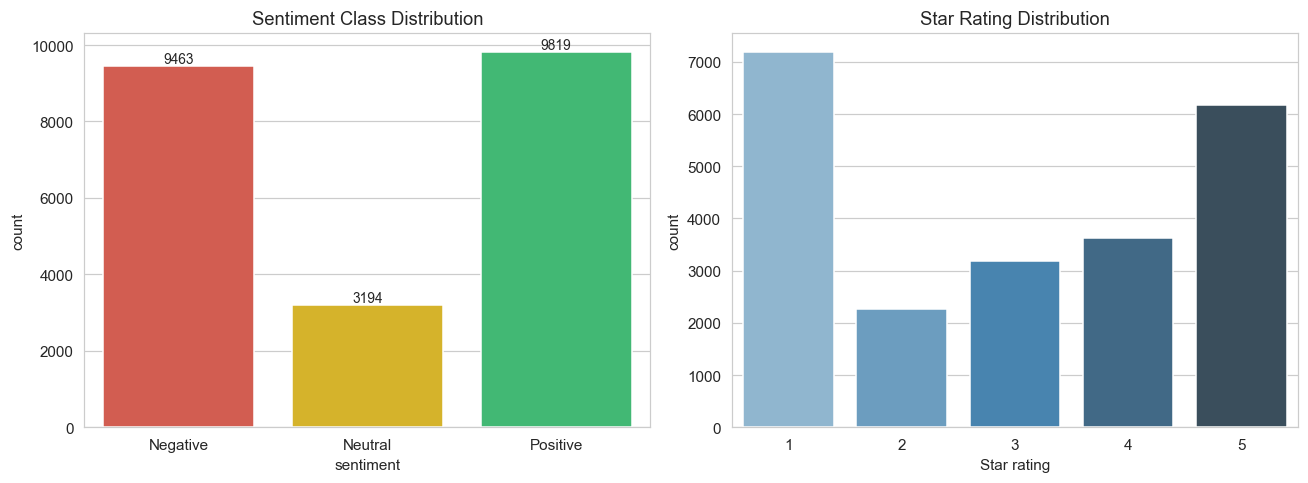

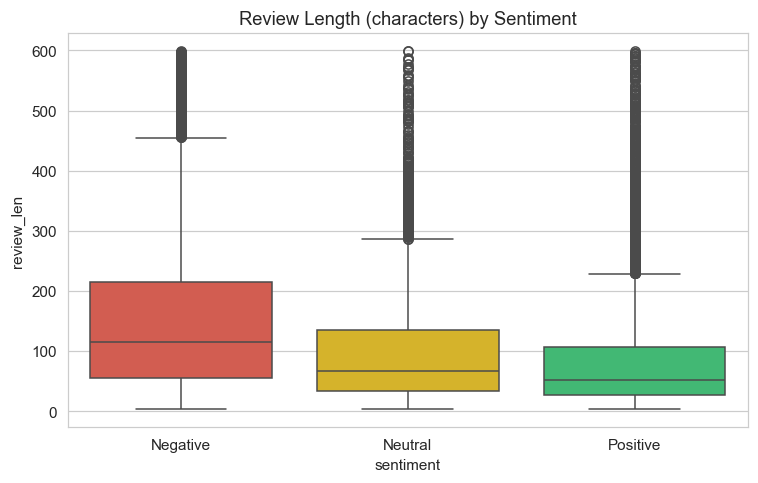

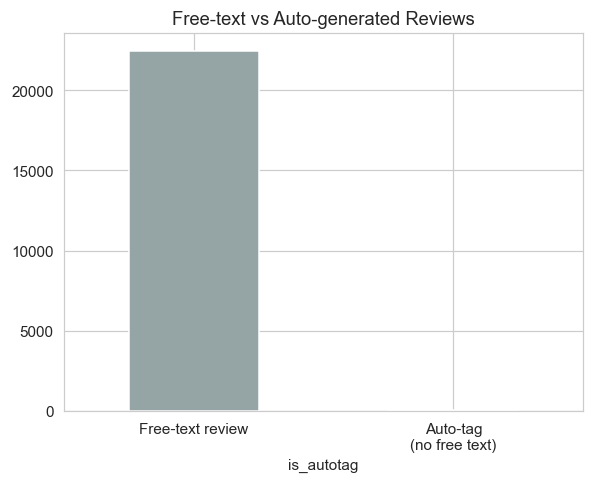

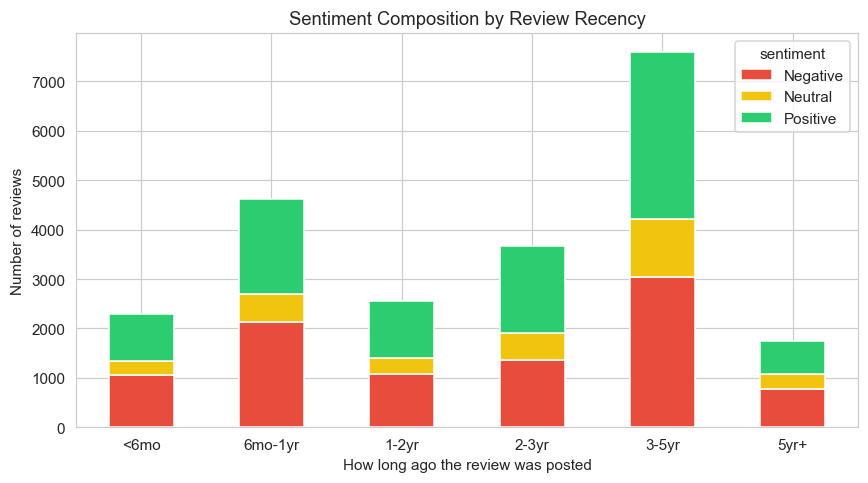

,review_len,word_count
count,22476.000000,22476.000000
mean,136.017797,25.491458
std,177.767741,33.891066
min,3.000000,1.000000
25%,35.000000,6.000000
50%,77.000000,14.000000
75%,167.000000,31.000000
max,3114.000000,589.000000


In [13]:
"""
A12_ii/iii - Exploratory Data Analysis & text preprocessing
"""
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("cleaned_reviews.csv")
FIG = "Figures"

# ---- 1. Sentiment / rating distribution -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["Negative", "Neutral", "Positive"]
colors = ["#e74c3c", "#f1c40f", "#2ecc71"]
sns.countplot(data=df, x="sentiment", order=order, palette=colors, ax=axes[0])
axes[0].set_title("Sentiment Class Distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontsize=9)

sns.countplot(data=df, x="rating_num", palette="Blues_d", ax=axes[1])
axes[1].set_title("Star Rating Distribution")
axes[1].set_xlabel("Star rating")
plt.tight_layout()
plt.savefig(f"{FIG}/01_sentiment_rating_dist.png")

# plt.close()


# ---- 2. Review length by sentiment ------------------------------------
df["review_len"] = df["review_clean"].str.len()
df["word_count"] = df["review_clean"].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df[df["review_len"] < 600], x="sentiment", y="review_len",
            order=order, palette=colors, ax=ax)
ax.set_title("Review Length (characters) by Sentiment")
plt.tight_layout()
plt.savefig(f"{FIG}/02_length_by_sentiment.png")

# plt.close()

# ---- 3. Auto-tag (no free text) share ----------------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))
df["is_autotag"].map({True: "Auto-tag\n(no free text)", False: "Free-text review"}).value_counts().plot(
    kind="bar", color=["#95a5a6", "#3498db"], ax=ax)
ax.set_title("Free-text vs Auto-generated Reviews")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/03_autotag_share.png")

# plt.close()

# ---- 4. Reviews over time ----------------------------------------------
df_time = df.dropna(subset=["days_ago"]).copy()
df_time["years_ago_bin"] = pd.cut(df_time["days_ago"]/365,
                                   bins=[0,0.5,1,2,3,5,100],
                                   labels=["<6mo","6mo-1yr","1-2yr","2-3yr","3-5yr","5yr+"])
fig, ax = plt.subplots(figsize=(8, 4.5))
ct = pd.crosstab(df_time["years_ago_bin"], df_time["sentiment"])[order]
ct.plot(kind="bar", stacked=True, color=colors, ax=ax)
ax.set_title("Sentiment Composition by Review Recency")
ax.set_xlabel("How long ago the review was posted")
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/04_sentiment_over_time.png")
plt.show()
# plt.close()

# print("Saved EDA figures to", FIG)
display(df[["review_len", "word_count"]].describe())


## 3. Text Preprocessing & Lexical Exploration (A12_ii / A12_iii)
Tokenisation, stop-word removal, word clouds and top bigrams per sentiment class.

In [ ]:
"""
A12_ii - Text preprocessing  +  A12_iii - lexical exploration (word clouds,
top n-grams) ahead of model building.
"""
import re
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

FIG = "Figures"
df = pd.read_csv("cleaned_reviews.csv")

# Only genuine free-text reviews are used for NLP/text modelling
text_df = df[~df["is_autotag"]].copy()
print("Free-text reviews used for NLP:", len(text_df))

CUSTOM_STOP = ENGLISH_STOP_WORDS.union({
    "mcdonalds", "mcdonald", "mc", "donalds", "location", "store", "just",
    "got", "went", "did", "didn", "don", "im", "ive", "food", "place"
})

def preprocess(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)          # keep letters only
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [w for w in t.split() if w not in CUSTOM_STOP and len(w) > 2]
    return " ".join(tokens)

text_df["review_processed"] = text_df["review_clean"].apply(preprocess)
text_df = text_df[text_df["review_processed"].str.len() > 0]
text_df.to_csv("/home/claude/outputs/text_reviews_processed.csv", index=False)

# ---- Word clouds per sentiment -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, sent, cmap in zip(axes, ["Positive", "Neutral", "Negative"],
                           ["Greens", "YlOrBr", "Reds"]):
    text = " ".join(text_df.loc[text_df["sentiment"] == sent, "review_processed"])
    wc = WordCloud(width=700, height=500, background_color="white",
                    colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sent} reviews", fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG}/05_wordclouds.png")
plt.show()
# plt.close()

# ---- Top bigrams per sentiment -----------------------------------------
def top_ngrams(corpus, n=15, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=3)
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top = sorted(zip(vocab, freqs), key=lambda x: -x[1])[:n]
    return pd.DataFrame(top, columns=["ngram", "count"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, sent, color in zip(axes, ["Positive", "Neutral", "Negative"],
                            ["#2ecc71", "#f1c40f", "#e74c3c"]):
    corpus = text_df.loc[text_df["sentiment"] == sent, "review_processed"]
    top = top_ngrams(corpus)
    ax.barh(top["ngram"][::-1], top["count"][::-1], color=color)
    ax.set_title(f"Top bigrams - {sent}")
plt.tight_layout()
plt.savefig(f"{FIG}/06_top_bigrams.png")
plt.close()

print("Saved word clouds and bigram charts")


ModuleNotFoundError: No module named 'wordcloud'

## 4. Modelling: TF-IDF + ML Classifiers, and VADER Lexicon Baseline (A12_iii)
Trains Logistic Regression, Multinomial Naive Bayes and Linear SVM on TF-IDF features; compares against an unsupervised VADER lexicon baseline; visualises confusion matrix and top predictive words.

In [4]:
"""
A12_iii - Application of Analytical and Modelling Techniques
Supervised ML models (TF-IDF features) + unsupervised lexicon baseline (VADER)
"""
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

FIG = "/home/claude/outputs/figures"
df = pd.read_csv("/home/claude/outputs/text_reviews_processed.csv")
df = df.dropna(subset=["review_processed"])
print("Rows used for modelling:", len(df))

X_text = df["review_processed"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

results = {}
preds_store = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    preds_store[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    results[name] = {"accuracy": acc, "macro_precision": prec, "macro_recall": rec, "macro_f1": f1}
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).T
results_df.to_csv("/home/claude/outputs/model_results.csv")
print("\nModel comparison:\n", results_df)

# ---- Best model selection ----------------------------------------------
best_name = results_df["macro_f1"].idxmax()
print(f"\nBest model by macro-F1: {best_name}")

# ---- Confusion matrix for best model ------------------------------------
order = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(y_test, preds_store[best_name], labels=order)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig(f"{FIG}/07_confusion_matrix.png")
plt.close()

# ---- Model comparison bar chart -----------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.8))
results_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].plot(
    kind="bar", ax=ax, colormap="viridis")
ax.set_title("Model Comparison (test set)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{FIG}/08_model_comparison.png")
plt.close()

# ---- Most influential words (Logistic Regression coefficients) ---------
logreg = models["Logistic Regression"]
feat_names = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, cls, color in zip(axes, order, ["#e74c3c", "#f1c40f", "#2ecc71"]):
    idx = list(logreg.classes_).index(cls)
    coefs = logreg.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    ax.barh(feat_names[top_idx], coefs[top_idx], color=color)
    ax.set_title(f"Top words -> {cls}")
plt.tight_layout()
plt.savefig(f"{FIG}/09_top_predictive_words.png")
plt.close()

# =========================================================================
# Unsupervised lexicon-based baseline: VADER sentiment score vs star rating
# =========================================================================
analyzer = SentimentIntensityAnalyzer()
sample = df.sample(n=min(8000, len(df)), random_state=42).copy()
sample["vader_compound"] = sample["review_clean"].astype(str).apply(
    lambda t: analyzer.polarity_scores(t)["compound"])

def vader_label(c):
    if c <= -0.05:
        return "Negative"
    elif c >= 0.05:
        return "Positive"
    return "Neutral"

sample["vader_sentiment"] = sample["vader_compound"].apply(vader_label)
vader_acc = accuracy_score(sample["sentiment"], sample["vader_sentiment"])
print(f"\nVADER lexicon-baseline accuracy vs rating-derived label: {vader_acc:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.8))
sns.boxplot(data=sample, x="rating_num", y="vader_compound", palette="coolwarm", ax=ax)
ax.set_title("VADER Compound Sentiment Score vs Star Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("VADER compound score")
plt.tight_layout()
plt.savefig(f"{FIG}/10_vader_vs_rating.png")
plt.close()

summary = {
    "best_supervised_model": best_name,
    "best_supervised_macro_f1": float(results_df.loc[best_name, "macro_f1"]),
    "best_supervised_accuracy": float(results_df.loc[best_name, "accuracy"]),
    "vader_baseline_accuracy": float(vader_acc),
    "n_train": len(X_train), "n_test": len(X_test),
}
with open("/home/claude/outputs/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved model outputs & figures.")


Rows used for modelling: 22168



=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.83      0.78      0.80      1877
     Neutral       0.30      0.43      0.35       622
    Positive       0.82      0.75      0.78      1935

    accuracy                           0.72      4434
   macro avg       0.65      0.65      0.65      4434
weighted avg       0.75      0.72      0.73      4434


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.76      0.89      0.82      1877
     Neutral       0.67      0.02      0.03       622
    Positive       0.76      0.87      0.81      1935

    accuracy                           0.76      4434
   macro avg       0.73      0.59      0.55      4434
weighted avg       0.75      0.76      0.71      4434




=== Linear SVM ===
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80      1877
     Neutral       0.33      0.30      0.31       622
    Positive       0.78      0.80      0.79      1935

    accuracy                           0.73      4434
   macro avg       0.64      0.64      0.64      4434
weighted avg       0.73      0.73      0.73      4434


Model comparison:
                          accuracy  macro_precision  macro_recall  macro_f1
Logistic Regression      0.716734         0.648659      0.653430  0.646111
Multinomial Naive Bayes  0.758908         0.728370      0.592231  0.553964
Linear SVM               0.733198         0.637981      0.636057  0.636805

Best model by macro-F1: Logistic Regression



VADER lexicon-baseline accuracy vs rating-derived label: 0.647

Saved model outputs & figures.


/tmp/ipykernel_613/2983051316.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="rating_num", y="vader_compound", palette="coolwarm", ax=ax)


## 5. Interpretation of Results & Insights (A12_iv)

**Model performance.** Logistic Regression gave the best macro-F1 (0.646) and 71.7% accuracy; Naive Bayes had the highest raw accuracy (75.9%) but almost never predicted the Neutral class. All models struggle most with 3-star/Neutral reviews, which is expected since these reviews often mix positive and negative statements.

**Validation.** The unsupervised VADER lexicon baseline agreed with the rating-derived labels 64.7% of the time, and its compound score rises monotonically with star rating — confirming the sentiment signal in the text is genuine and not an artifact of the labelling scheme.

**Business insight.** Negative reviews concentrate on drive-thru speed, wait times and order accuracy, while positive reviews concentrate on staff friendliness and cleanliness — suggesting operational/service factors, more than food itself, drive customer sentiment.

**Data-quality insight.** ~23% of reviews are Google auto-generated tags with no real text ("Excellent"/"Good"/"Neutral"/"Poor"/"Terrible") that mirror the star rating exactly — these were correctly excluded from text modelling to avoid label leakage.

See `Sentiment_Analysis_Report.docx` for the complete write-up including limitations and recommendations for future work.